In [1]:
# Cell 1: choose dataset, VAE run/checkpoint, and persist the selection.
from pathlib import Path
import importlib
import json
import sys

import matplotlib.pyplot as plt

def find_project_root(start=Path.cwd()):
    start = Path(start).expanduser().resolve()
    for path in [start, *start.parents]:
        if (path / "setup.py").exists() and (path / "diffusionsr").exists():
            return path
    raise RuntimeError("Could not find LPBFDiffusionSR project root")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from diffusionsr.analysis import latent_stability as lsa
importlib.reload(lsa)

PROJECT_ROOT = lsa.find_project_root(PROJECT_ROOT)

# Set DATASET_ROOT to an explicit split root, or leave None to use root_folder from configuration.yml.
DATASET_ROOT = None

# VAE_PATH may be a run directory or a concrete .pth file. Leave None to search CHECKPOINT_SEARCH_ROOTS.
VAE_PATH = "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_12_13_55_01/standardize/n_steps_1/best_model.pth"
CHECKPOINT_NAME = "best_model.pth"  # e.g. "best_model.pth", "ckpt.pth", or None for CHECKPOINT_INDEX
CHECKPOINT_INDEX = 0
CHECKPOINT_SEARCH_ROOTS = [
    PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "vae3d",
    PROJECT_ROOT / "diffusionsr" / "runs" / "direct" / "vae2d",
]

# If the VAE run does not contain configuration.yml, point CONFIG_PATH to the training config.
CONFIG_PATH = None

# Which tensor to pass through the VAE encoder. None uses the VAE checkpoint's input_type.
EMBED_DATA_TYPE = None  # "hr", "upscaled_lr", "lr", or "residual"

# Leave OUTPUT_DIR as None to create a checkpoint-specific folder under analysis/latent_stability_outputs.
OUTPUT_DIR = None

state = lsa.setup_analysis(
    dataset_root=DATASET_ROOT,
    vae_path=VAE_PATH,
    checkpoint_name=CHECKPOINT_NAME,
    checkpoint_index=CHECKPOINT_INDEX,
    config_path=CONFIG_PATH,
    output_dir=OUTPUT_DIR,
    splits=("train", "test"),
    embed_data_type=EMBED_DATA_TYPE,
    search_roots=CHECKPOINT_SEARCH_ROOTS,
    save_selection=True,
)

lsa.print_checkpoint_options(state.checkpoint_options, limit=20)
print(json.dumps(state.summary(), indent=2, default=str))

/project/community/sboseban/miniforge3/envs/lpbfdiffusion/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using normalize method: ... standardize
Using specific fields, ['temperature', 'liqlabel', 'meltregion']
Processing dataset with 3 fields
Downscale factor:  4
Using normalize method: ... standardize
Using specific fields, ['temperature', 'liqlabel', 'meltregion']
Processing dataset with 3 fields
Downscale factor:  4
  0: /home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_12_13_55_01/standardize/n_steps_1/best_model.pth
{
  "project_root": "/home/sboseban/code/LPBFDiffusionSR_dev",
  "dataset_root": "/project/community/sboseban/Multifield_Split/ti6al4v_processed_3d_fields_seed20260518",
  "checkpoint_path": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_12_13_55_01/standardize/n_steps_1/best_model.pth",
  "config_path": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/runs/direct/vae3d/2026_06_12_13_55_01/standardize/n_steps_1/configuration.yml",
  "output_dir": "/home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/analysis/l

In [4]:
# Cell 2: embed train/test splits and save the latent maps plus flattened vectors.
EMBED_BATCH_SIZE = 30
MAX_SAMPLES_PER_SPLIT = None  # set a small int for quick smoke tests
EMBED_SAMPLE_POSTERIOR = False  # False uses deterministic latent means

embeddings = lsa.embed_splits(
    state,
    splits=("train", "test"),
    batch_size=EMBED_BATCH_SIZE,
    max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
    sample_posterior=EMBED_SAMPLE_POSTERIOR,
)

print("saved:", embeddings["path"])
for split in ("train", "test"):
    print(split, {
        "vectors": embeddings[split]["vectors"].shape,
        "latents": embeddings[split]["latents"].shape,
        "power_range": (float(embeddings[split]["power"].min()), float(embeddings[split]["power"].max())),
        "velocity_range": (float(embeddings[split]["velocity"].min()), float(embeddings[split]["velocity"].max())),
        "led_range": (float(embeddings[split]["led"].min()), float(embeddings[split]["led"].max())),
    })

saved: /home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/analysis/latent_stability_outputs/vae3d_2026_06_12_13_55_01_standardize_n_steps_1/embeddings_hr_best_model.npz
train {'vectors': (2926, 10240), 'latents': (2926, 8, 20, 8, 8), 'power_range': (104.0, 416.0), 'velocity_range': (400.0, 1200.0), 'led_range': (0.13416666666666666, 0.6933333333333334)}
test {'vectors': (403, 10240), 'latents': (403, 8, 20, 8, 8), 'power_range': (106.0, 363.0), 'velocity_range': (400.0, 700.0), 'led_range': (0.15142857142857144, 0.5185714285714286)}


PCA explained variance ratio: [0.46760038 0.11445855 0.06569459 0.04611218 0.03471586 0.03345752
 0.02503868 0.02341115]
t-SNE perplexity used: 30.0


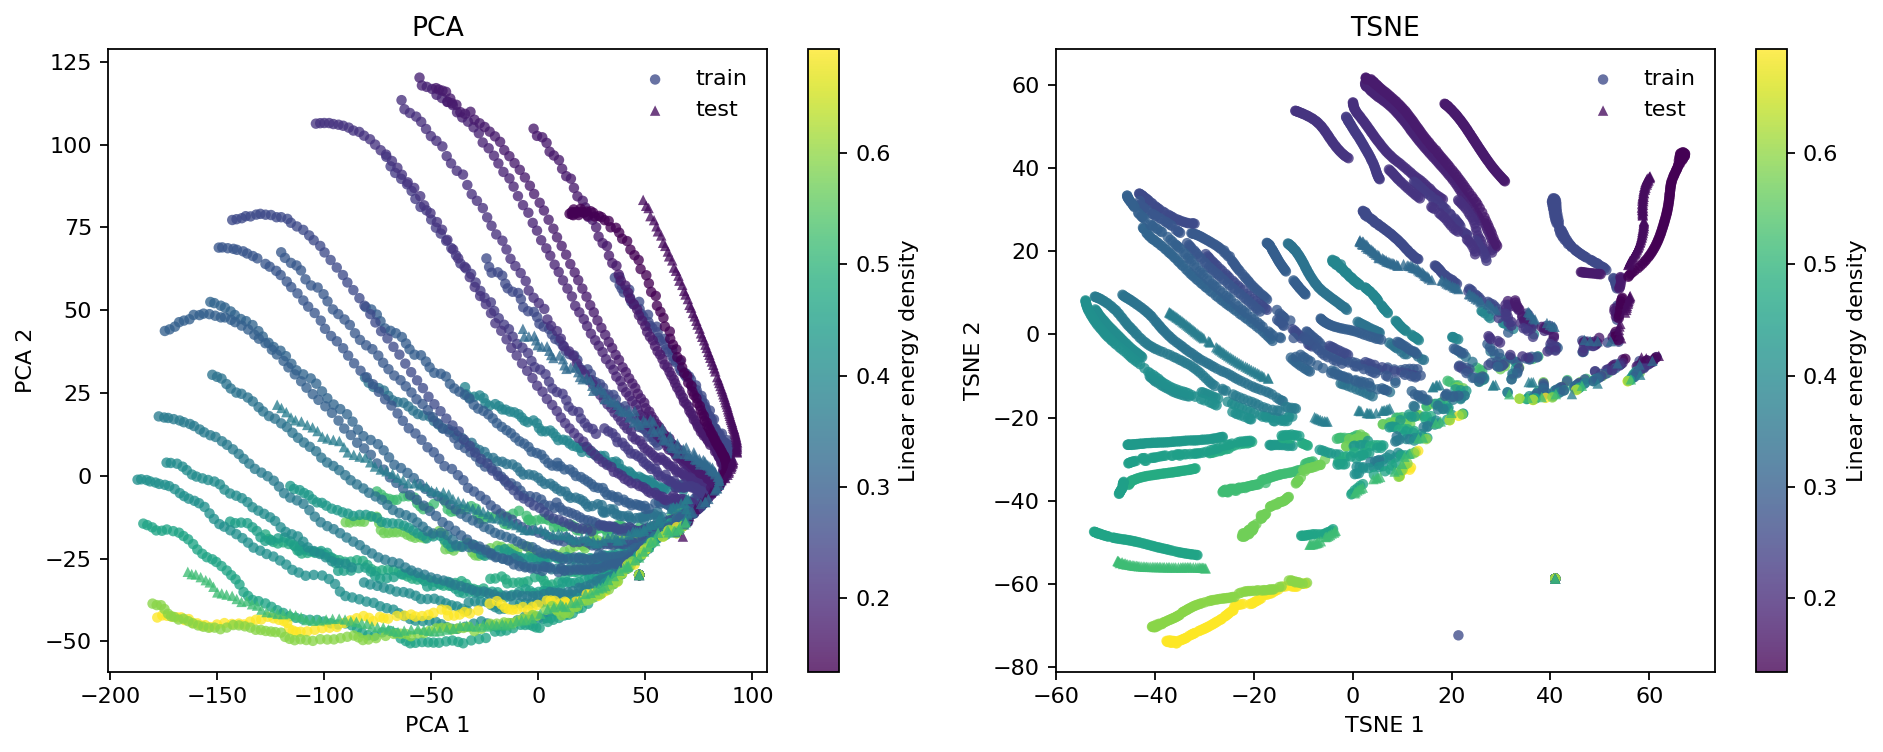

In [5]:
# Cell 3: run PCA and t-SNE on train/test embeddings and color by process variables.
TSNE_PERPLEXITY = 30
COLOR_BY = "led"  # "power", "velocity", or "led"
PCA_COMPONENTS = 8
RANDOM_STATE = 0

projection_dir = state.output_dir / "projections"
projections = lsa.run_latent_projections(
    embeddings,
    perplexity=TSNE_PERPLEXITY,
    color_by=COLOR_BY,
    pca_components=PCA_COMPONENTS,
    random_state=RANDOM_STATE,
    output_dir=projection_dir,
    save=True,
)

print("PCA explained variance ratio:", projections["pca"]["explained_variance_ratio"][:PCA_COMPONENTS])
print("t-SNE perplexity used:", projections["tsne"]["perplexity"])

PCA explained variability by component:
  PC1: 46.76%
  PC2: 11.45%
  PC3: 6.57%
  PC4: 4.61%
  PC5: 3.47%
  PC6: 3.35%
  PC7: 2.50%
  PC8: 2.34%
cumulative explained variability (8 PCs): 81.05%
saved: /home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/analysis/latent_stability_outputs/vae3d_2026_06_12_13_55_01_standardize_n_steps_1/projections/projection_collage.png


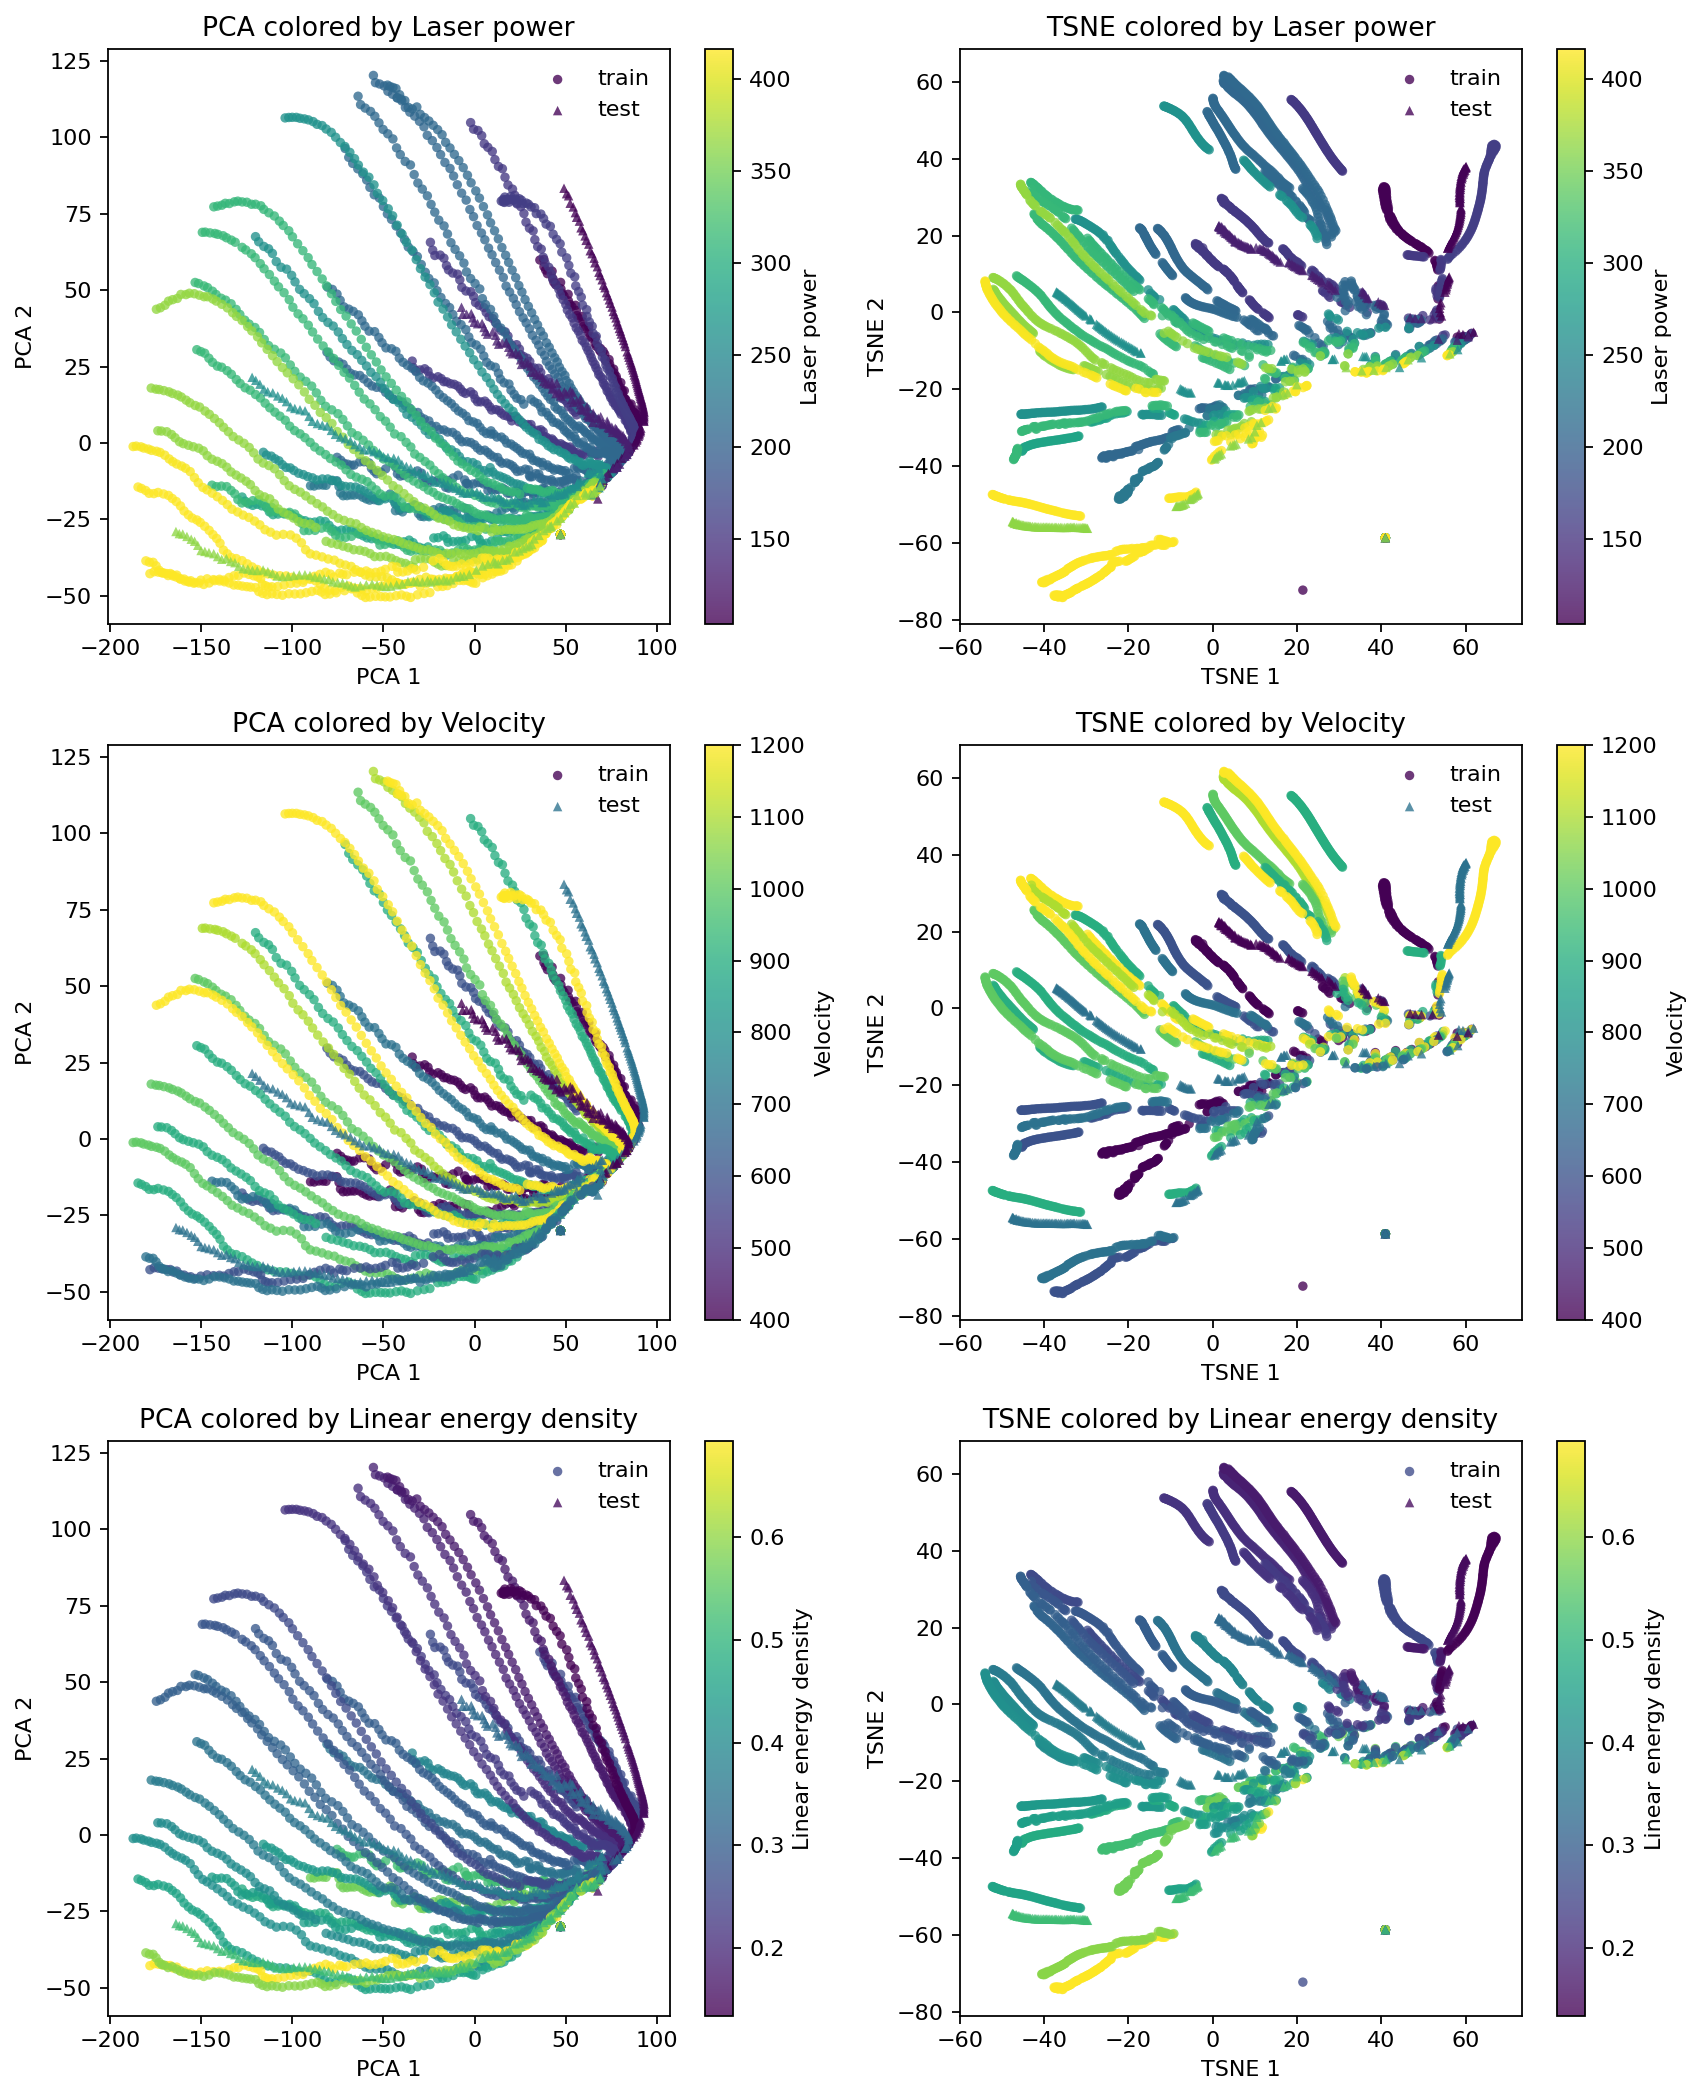

In [6]:
# Cell 4: make a compact collage of projection plots for all supported color modes.
COLLAGE_COLOR_MODES = ("power", "velocity", "led")
COLLAGE_PROJECTIONS = ("pca", "tsne")
COLLAGE_PATH = state.output_dir / "projections" / "projection_collage.png"

collage_fig = lsa.make_projection_collage(
    projections,
    embeddings,
    color_modes=COLLAGE_COLOR_MODES,
    projection_names=COLLAGE_PROJECTIONS,
    save_path=COLLAGE_PATH,
)

pca_explained_variability = projections["pca"]["explained_variance_ratio"]
n_reported_pcs = min(PCA_COMPONENTS, len(pca_explained_variability))
cumulative_explained_variability = float(pca_explained_variability[:n_reported_pcs].sum())
print("PCA explained variability by component:")
for pc_index, ratio in enumerate(pca_explained_variability[:n_reported_pcs], start=1):
    print(f"  PC{pc_index}: {100.0 * float(ratio):.2f}%")
print(f"cumulative explained variability ({n_reported_pcs} PCs): {100.0 * cumulative_explained_variability:.2f}%")
print("saved:", COLLAGE_PATH)

saved: /home/sboseban/code/LPBFDiffusionSR_dev/diffusionsr/analysis/latent_stability_outputs/vae3d_2026_06_12_13_55_01_standardize_n_steps_1/projections/pca_3d_led.png


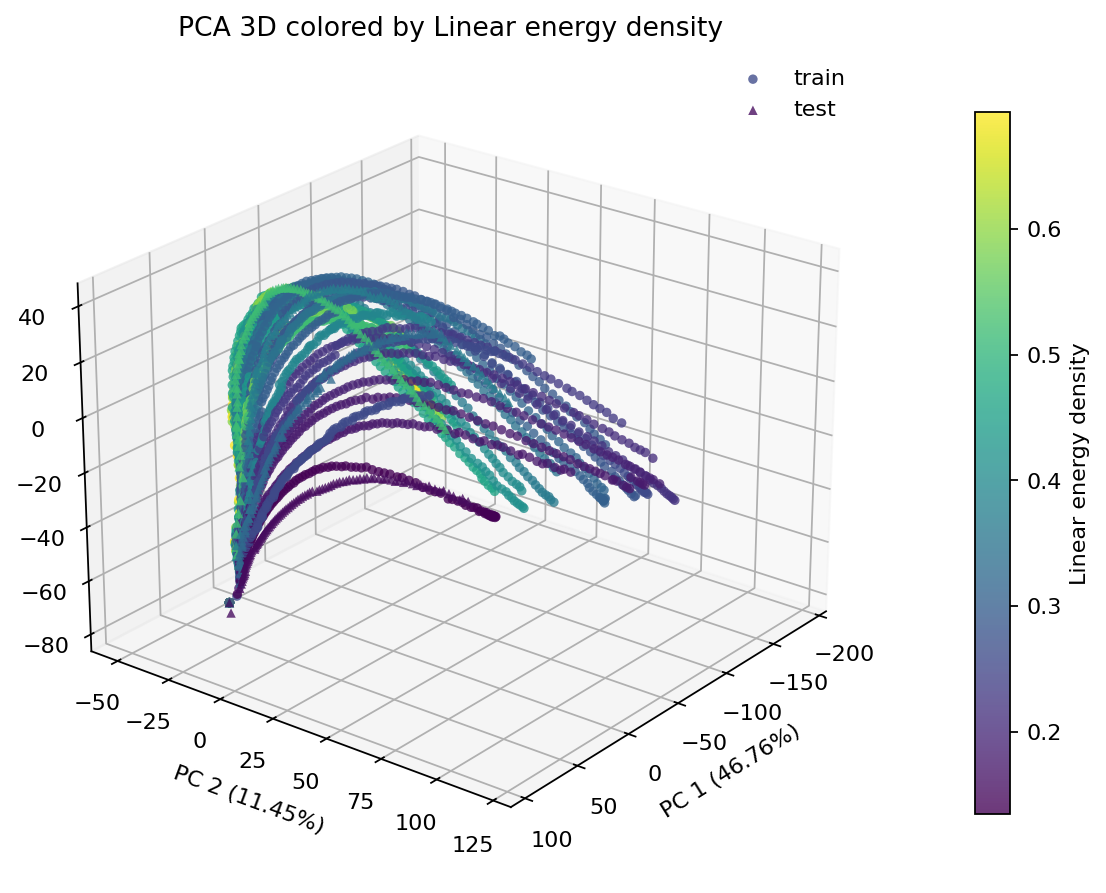

In [18]:
# Cell 4b: generate a 3D PCA plot of the first three principal components.
import numpy as np

PC3D_COLOR_BY = COLOR_BY
PC3D_PATH = state.output_dir / "projections" / f"pca_3d_{lsa.canonical_property(PC3D_COLOR_BY)}.png"

pca_scores_by_split = projections["pca"]
pca_explained_variability = projections["pca"]["explained_variance_ratio"]
if pca_scores_by_split["all"].shape[1] < 3:
    raise ValueError("Set PCA_COMPONENTS >= 3 before running the 3D PC plot cell.")

pc3d_color_by = lsa.canonical_property(PC3D_COLOR_BY)
all_colors = np.concatenate([lsa.property_values(embeddings, split, pc3d_color_by) for split in ("train", "test")])
vmin, vmax = np.nanpercentile(all_colors, [1, 99])
if np.isclose(vmin, vmax):
    vmin, vmax = None, None

pc3d_fig = plt.figure(figsize=(7.2, 6.4), dpi=160)
pc3d_ax = pc3d_fig.add_subplot(111, projection="3d")
last = None
for split, marker, label in [("train", "o", "train"), ("test", "^", "test")]:
    coords = np.asarray(pca_scores_by_split[split])
    colors = lsa.property_values(embeddings, split, pc3d_color_by)
    last = pc3d_ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        c=colors,
        s=18,
        marker=marker,
        cmap="viridis",
        vmin=vmin,
        vmax=vmax,
        alpha=0.78,
        edgecolors="none",
        label=label,
    )

pc3d_ax.set_title(f"PCA 3D colored by {lsa.projection_color_label(pc3d_color_by)}")
pc3d_ax.set_xlabel(f"PC 1 ({100.0 * float(pca_explained_variability[0]):.2f}%)")
pc3d_ax.set_ylabel(f"PC 2 ({100.0 * float(pca_explained_variability[1]):.2f}%)")
pc3d_ax.set_zlabel(f"PC 3 ({100.0 * float(pca_explained_variability[2]):.2f}%)")
pc3d_ax.view_init(elev=24, azim=38)
pc3d_ax.legend(frameon=False)
if last is not None:
    pc3d_fig.colorbar(last, ax=pc3d_ax, shrink=0.72, pad=0.1, label=lsa.projection_color_label(pc3d_color_by))

pc3d_fig.tight_layout()
PC3D_PATH.parent.mkdir(parents=True, exist_ok=True)
pc3d_fig.savefig(PC3D_PATH, bbox_inches="tight")
print("saved:", PC3D_PATH)

{
  "power": {
    "train_fit": {
      "train": {
        "r2": 0.9900765764662961,
        "rmse": 8.813541093757717,
        "mae": 0.7545195278126676
      },
      "test": {
        "r2": -1.161962861611518,
        "rmse": 152.3340384232678,
        "mae": 108.17101455054775
      }
    },
    "separate_fit": {
      "train": {
        "r2": 0.9900765764662961,
        "rmse": 8.813541093757717,
        "mae": 0.7545195278126676
      },
      "test": {
        "r2": 0.9900719974685492,
        "rmse": 10.322948969855616,
        "mae": 0.9578163771721231
      }
    }
  },
  "led": {
    "train_fit": {
      "train": {
        "r2": 0.9900837154990982,
        "rmse": 0.013509798973960084,
        "mae": 0.0010991553237061978
      },
      "test": {
        "r2": -14.817777991336623,
        "rmse": 0.5199944596103563,
        "mae": 0.35004389655115353
      }
    },
    "separate_fit": {
      "train": {
        "r2": 0.9900837154990982,
        "rmse": 0.013509798973960084,


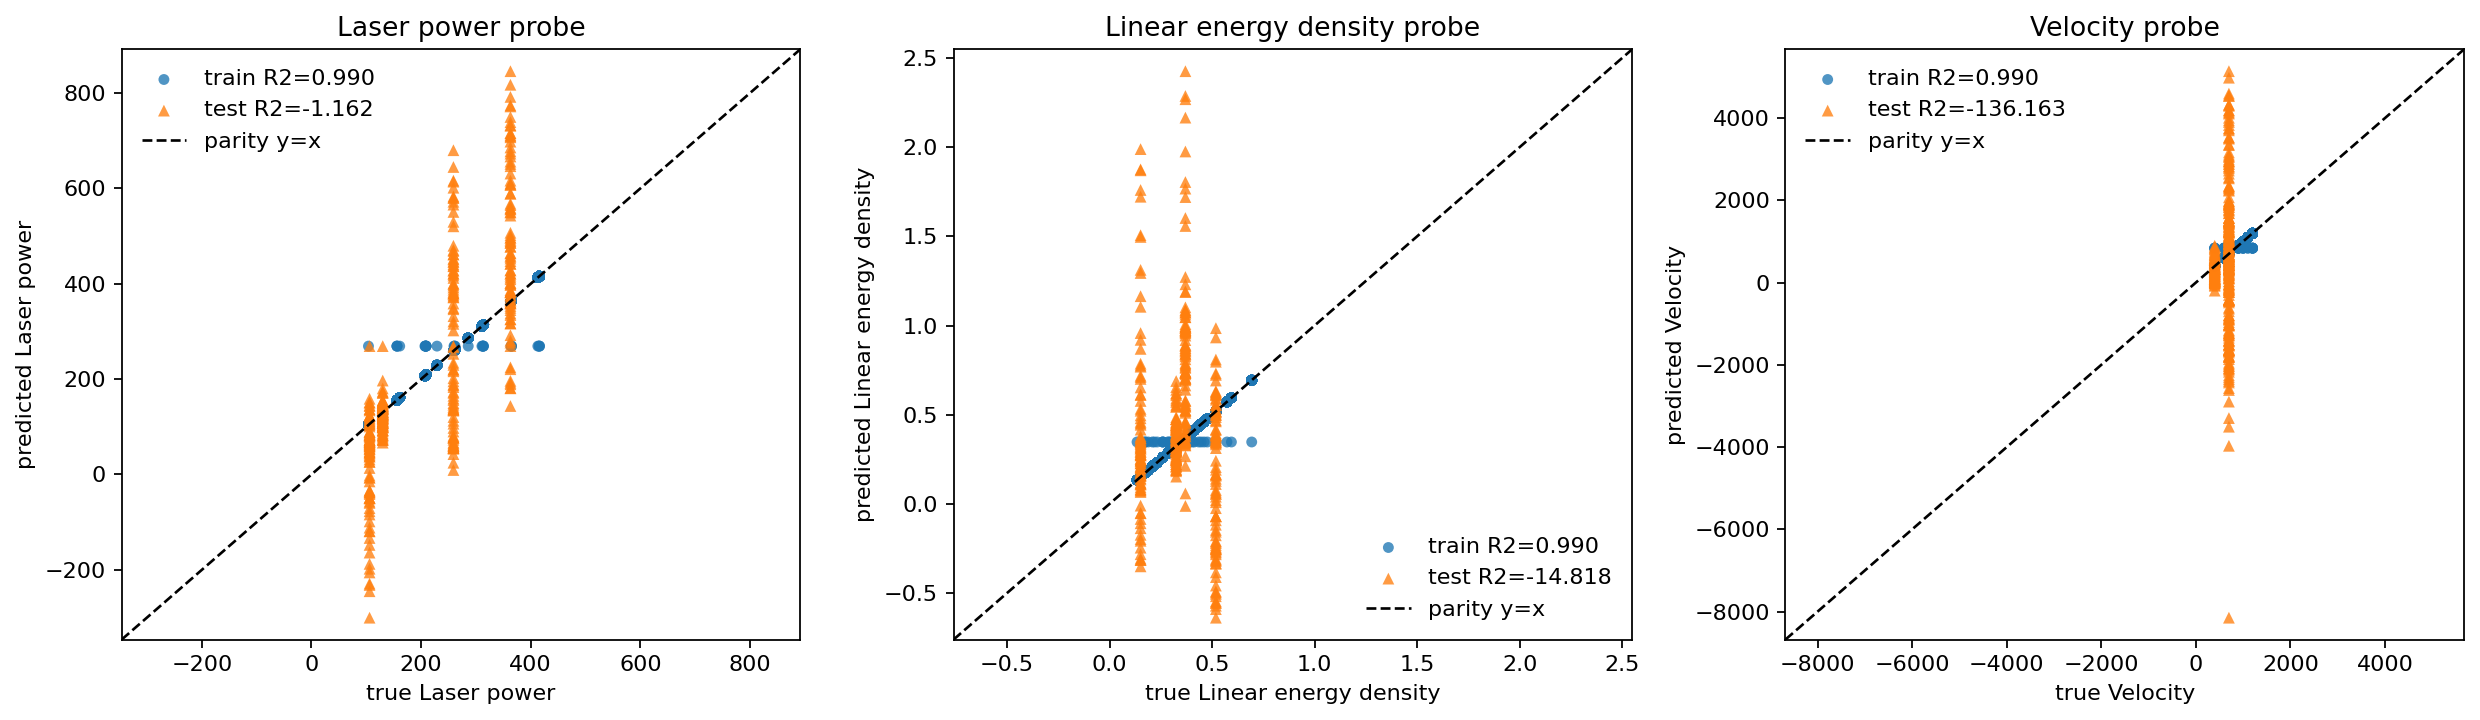

In [7]:
# Cell 5: fit linear probes for process variables and make parity plots.
PROBE_TARGETS = ("power", "led", "velocity")
SOLVE_SPLITS_SEPARATELY = True
probe_dir = state.output_dir / "probes"

probe_results = lsa.fit_linear_probes(
    embeddings,
    targets=PROBE_TARGETS,
    solve_splits_separately=SOLVE_SPLITS_SEPARATELY,
    output_dir=probe_dir,
    save=True,
)

print(json.dumps(probe_results["metrics"], indent=2, default=float))

interpolation mode: samples


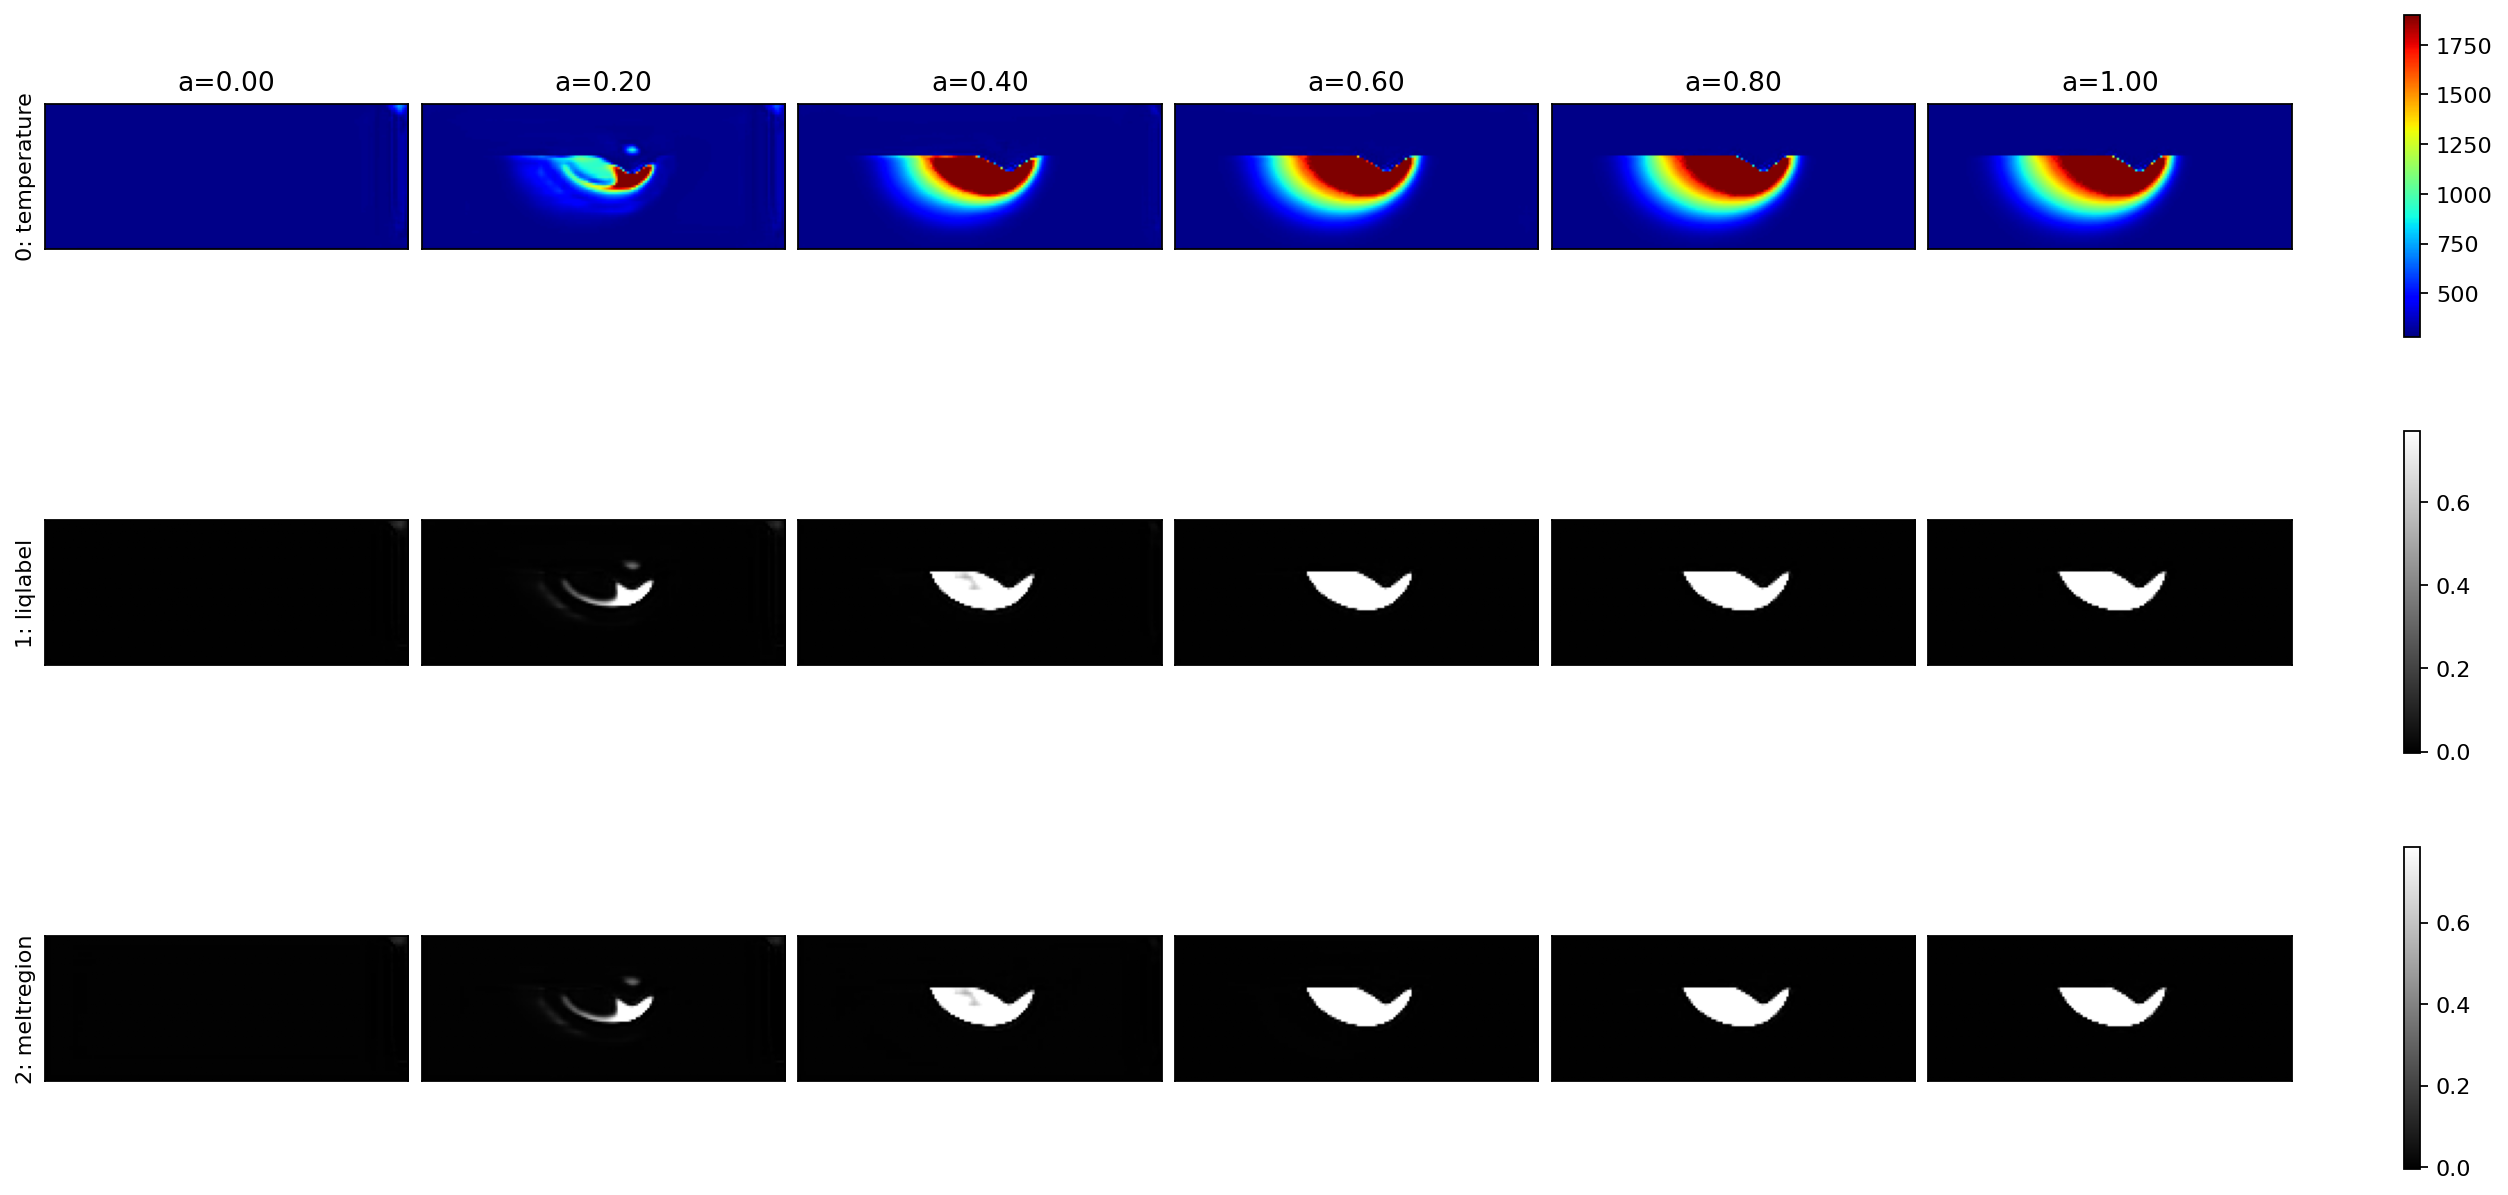

In [17]:
# Cell 6: interpolate in latent space, decode, and visualize intermediate fields.
# Modes:
#   "samples" interpolates between two embedded samples.
#   "probe" moves an anchor latent along one or more fitted P/V/LED probe directions.
#   "pca" moves an anchor latent along selected PCA components.
INTERPOLATION_MODE = "samples"  # "samples", "probe", or "pca"
INTERPOLATION_SPLIT = "train"
INTERPOLATION_STEPS = 6

# For sample-to-sample interpolation.
INDEX_A = 0
INDEX_B = 99

# For probe and PCA interpolation.
ANCHOR_INDEX = 886
PROBE_FIELDS = ("led","power")  # single: ("led",), multi: ("power", "velocity") or ("power", "velocity", "led")
PROBE_TARGET_VALUES = None  # None spans observed 10th-90th percentiles, or use {"led": [low, high]}
PCA_COMPONENTS_TO_INTERPOLATE = (0, 1)
PCA_SIGMA_RANGE = (-2.0, 2.0)

# For decoded plots. None shows the first few channels; strings work for multifield runs.
INTERPOLATION_CHANNELS = None  # examples: [0], ["temperature"], ["temperature", "liqlabel", "meltregion"]
INTERPOLATION_AXIS = "y"  # for 3D outputs: "x", "y", or "z"
INTERPOLATION_DEPTH_INDEX = None  # None uses the center slice

interpolation_result = lsa.run_latent_interpolation(
    state,
    embeddings,
    mode=INTERPOLATION_MODE,
    projections=globals().get("projections"),
    probe_results=globals().get("probe_results"),
    split=INTERPOLATION_SPLIT,
    index_a=INDEX_A,
    index_b=INDEX_B,
    anchor_index=ANCHOR_INDEX,
    steps=INTERPOLATION_STEPS,
    channels=INTERPOLATION_CHANNELS,
    axis=INTERPOLATION_AXIS,
    depth_index=INTERPOLATION_DEPTH_INDEX,
    probe_fields=PROBE_FIELDS,
    probe_target_values=PROBE_TARGET_VALUES,
    pca_components=PCA_COMPONENTS_TO_INTERPOLATE,
    pca_sigma_range=PCA_SIGMA_RANGE,
    output_dir=state.output_dir / "interpolations",
)

print("interpolation mode:", INTERPOLATION_MODE)